# 04 · Goals & Outcome Model
Phase 4: Dixon-Coles model + XGBoost classifier + ensemble.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from src.data_loader import load_all
from src.dixon_coles import DixonColes, tune_xi
from src.models import XGBOutcomeModel, EnsemblePredictor
np.random.seed(42)

data = load_all(verbose=False)
results_full = data['results_full']
results = data['results_primary']
wc_2022 = results_full[results_full['is_wc'] & (results_full['date'].dt.year == 2022)].copy()
train_dc = results_full[(results_full['date'].dt.year >= 2015) & 
                         (results_full['date'].dt.year < 2022)].copy()
print(f"Dixon-Coles train: {len(train_dc):,} | 2022 WC validation: {len(wc_2022):,}")


INFO | Loading results from /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/raw/results.csv


INFO |   Raw rows: 49,477


WARNING |   Found 2 duplicate match entries — dropping


INFO |   Full dataset: 49,475 rows | Primary (1990+): 32,358


INFO | former_names.csv columns: ['current', 'former', 'start_date', 'end_date']


...

INFO | Loaded knockout slots: 32 matches


INFO | Loaded FIFA rankings for 48 teams


INFO | Loaded WC historical stats: 964 matches (1930-2022)


INFO | Saved team_registry.csv: 48 teams → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/team_registry.csv


Dixon-Coles train: 6,423 | 2022 WC validation: 164


## 4.1 Tune Dixon-Coles xi (time-decay)

INFO | Grid searching xi over [0.001, 0.003, 0.005]


INFO | Fitting Dixon-Coles on 6,423 matches, 284 teams


INFO |   Running L-BFGS-B optimisation...


Grid searching best xi (time-decay parameter)...


WARNING |   Optimisation did not fully converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT


...

WARNING |   Optimisation did not fully converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT


INFO |   home_adv=0.2233, rho=-0.0857


INFO |   xi=0.005 → RPS=0.2126, acc=0.488


INFO | Best xi: 0.001 (RPS=0.2081)



Best xi = 0.001  |  Best RPS = 0.2081


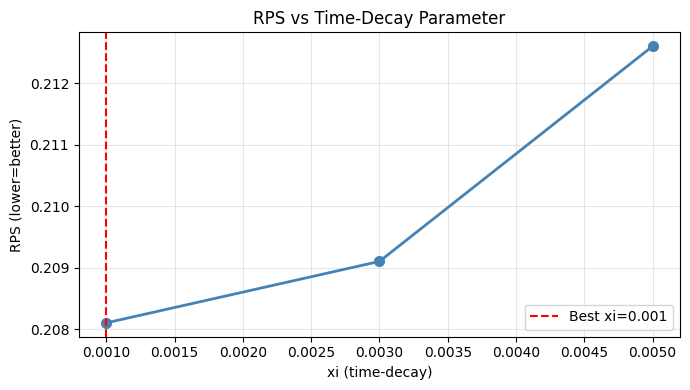

In [2]:
print("Grid searching best xi (time-decay parameter)...")
xi_results = tune_xi(train_dc, wc_2022, xi_values=[0.001, 0.003, 0.005])
best_xi = xi_results['best_xi']
print(f"\nBest xi = {best_xi:.3f}  |  Best RPS = {xi_results['best_rps']:.4f}")

plt.figure(figsize=(7, 4))
xi_df = pd.DataFrame(xi_results['results'])
plt.plot(xi_df['xi'], xi_df['rps'], 'o-', color='steelblue', lw=2, ms=7)
plt.axvline(best_xi, color='red', linestyle='--', label=f'Best xi={best_xi}')
plt.xlabel('xi (time-decay)'); plt.ylabel('RPS (lower=better)')
plt.title('RPS vs Time-Decay Parameter'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/xi_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.2 Fit Final Dixon-Coles Model (All Data 2000-2026)

In [3]:
train_final = results_full[results_full['date'].dt.year >= 2015].copy()
print(f"Fitting final Dixon-Coles on {len(train_final):,} matches...")

dc_model = DixonColes(xi=best_xi)
dc_model.fit(train_final)
dc_model.save_params()

print(f"home_advantage = {dc_model._home_adv:.4f}")
print(f"rho (low-score correction) = {dc_model._rho:.4f}")
print("\nValidating on 2022 WC...")
val_metrics = dc_model.validate(wc_2022)
print(f"  RPS = {val_metrics['rps']:.4f}  |  Accuracy = {val_metrics['accuracy']:.2%}  |  n = {val_metrics['n']}")

# Show team attack/defense ratings
import json
params = dc_model.params_
team_params = pd.DataFrame([
    {'team': t, 'alpha': v['alpha'], 'beta': v['beta']}
    for t, v in params['teams'].items()
]).sort_values('alpha', ascending=False)
print("\nTop 10 Attack (alpha):")
print(team_params.head(10).to_string(index=False))


INFO | Fitting Dixon-Coles on 11,038 matches, 295 teams


INFO |   Running L-BFGS-B optimisation...


Fitting final Dixon-Coles on 11,062 matches...


WARNING |   Optimisation did not fully converge: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT


INFO |   home_adv=0.2493, rho=-0.0152


INFO | Saved Dixon-Coles params to /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/outputs/model_artifacts/dixon_coles_params.json


home_advantage = 0.2493
rho (low-score correction) = -0.0152

Validating on 2022 WC...


  RPS = 0.1952  |  Accuracy = 60.37%  |  n = 164

Top 10 Attack (alpha):
       team  alpha    beta
     Brazil 1.1802 -0.9606
      Spain 1.1561 -1.0346
   Colombia 1.1200 -1.0045
    Germany 1.1176 -0.5712
  Argentina 1.0903 -1.5414
   Portugal 1.0852 -0.8066
     France 1.0581 -0.9096
      Japan 1.0208 -1.0411
Netherlands 1.0190 -0.6355
    Belgium 0.9137 -0.7280


## 4.3 Example Predictions from Dixon-Coles

In [4]:
test_matches = [
    ('France', 'Brazil', True),
    ('Argentina', 'Germany', True),
    ('Spain', 'England', True),
    ('Morocco', 'USA', True),
    ('Japan', 'Ecuador', True),
]
print(f"{'Home':<15} {'Away':<15} {'P(H)':<8} {'P(D)':<8} {'P(A)':<8} {'Score'}")
print("-" * 60)
for home, away, neutral in test_matches:
    try:
        probs = dc_model.predict_outcome_probs(home, away, neutral)
        score = dc_model.predict_scoreline(home, away, neutral)
        print(f"{home:<15} {away:<15} {probs['home']:<8.3f} {probs['draw']:<8.3f} "
              f"{probs['away']:<8.3f} {score[0]}-{score[1]}")
    except Exception as e:
        print(f"{home:<15} {away:<15} ERROR: {e}")


Home            Away            P(H)     P(D)     P(A)     Score
------------------------------------------------------------
France          Brazil          0.350    0.270    0.380    1-1
Argentina       Germany         0.670    0.211    0.118    1-0
Spain           England         0.439    0.302    0.259    1-0
Morocco         USA             0.587    0.271    0.142    1-0
Japan           Ecuador         0.400    0.358    0.243    0-0


## 4.4 XGBoost Outcome Classifier

In [5]:
feat_path = '../data/processed/match_features.csv'
feat_df = pd.read_csv(feat_path, parse_dates=['date'])
train_xgb = feat_df[feat_df['date'].dt.year >= 2010].dropna(subset=['outcome'])
print(f"XGBoost training set: {len(train_xgb):,} matches")

xgb_model = XGBOutcomeModel()
print("Running Optuna tuning (50 trials)...")
xgb_model.tune_and_fit(train_xgb, n_trials=50)
xgb_model.save()

print("\nTop feature importances:")
imp = sorted(xgb_model.feature_importance.items(), key=lambda x: -x[1])
for feat, score in imp[:8]:
    print(f"  {feat:<35} {score:.4f}")


XGBoost training set: 15,864 matches
Running Optuna tuning (50 trials)...


INFO | XGBoost tuning: 15864 samples, 18 features, 50 trials


INFO | Best XGB params: {'n_estimators': 317, 'max_depth': 3, 'learning_rate': 0.040431253198494194, 'subsample': 0.7331813229479764, 'colsample_bytree': 0.7653182735831828, 'reg_alpha': 3.3433608718412873, 'reg_lambda': 3.3425839189142774}


INFO | Best CV accuracy: 0.5926


INFO | Top-5 features: [('elo_diff', np.float32(0.28457007)), ('elo_ratio', np.float32(0.27308333)), ('h2h_diff', np.float32(0.06711483)), ('is_neutral', np.float32(0.05628165)), ('conf_away', np.float32(0.03553644))]


INFO | Saved XGBoost model → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/outputs/model_artifacts/xgb_outcome.pkl



Top feature importances:
  elo_diff                            0.2846
  elo_ratio                           0.2731
  h2h_diff                            0.0671
  is_neutral                          0.0563
  conf_away                           0.0355
  goals_conceded_avg_home             0.0341
  goals_conceded_avg_away             0.0295
  form_diff_10                        0.0281


## 4.5 Ensemble & SHAP Analysis

In [6]:
ensemble = EnsemblePredictor(dc_weight=0.6, xgb_weight=0.4)
print("Ensemble: 60% Dixon-Coles + 40% XGBoost")

# SHAP values
try:
    import shap
    shap_vals = xgb_model.get_shap_values(train_xgb.head(500))
    if shap_vals is not None:
        print("\nSHAP summary computed (see plot)")
        # Simple bar plot of mean |SHAP|
        feat_cols_used = [c for c in xgb_model.FEATURE_COLS if c in train_xgb.columns]
        if isinstance(shap_vals, list):
            mean_shap = np.mean([np.abs(sv).mean(0) for sv in shap_vals], axis=0)
        else:
            mean_shap = np.abs(shap_vals).mean(0)
        shap_df = pd.DataFrame({'feature': feat_cols_used, 'importance': mean_shap}).sort_values('importance', ascending=False)
        plt.figure(figsize=(8, 5))
        plt.barh(shap_df['feature'].head(10)[::-1], shap_df['importance'].head(10)[::-1], color='steelblue')
        plt.xlabel('Mean |SHAP value|'); plt.title('Top 10 Features by SHAP Importance')
        plt.tight_layout()
        plt.savefig('../outputs/plots/shap_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
except Exception as e:
    print(f"SHAP skipped: {e}")


Ensemble: 60% Dixon-Coles + 40% XGBoost



SHAP summary computed (see plot)
SHAP skipped: Per-column arrays must each be 1-dimensional


## ✅ Phase 4 Complete
- Dixon-Coles model fitted and validated
- XGBoost classifier tuned with Optuna
- Model saved to `outputs/model_artifacts/`